### Astrostatistic Lecture 17

/tmp/ipykernel_3488/2914343376.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', color='white')


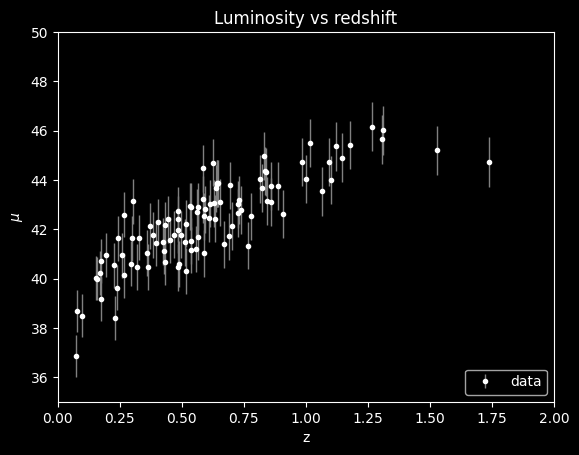

In [2]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
import numpy as np
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50);

39.60456481105869 [4.5911933]


/tmp/ipykernel_3488/315978152.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', color='white')


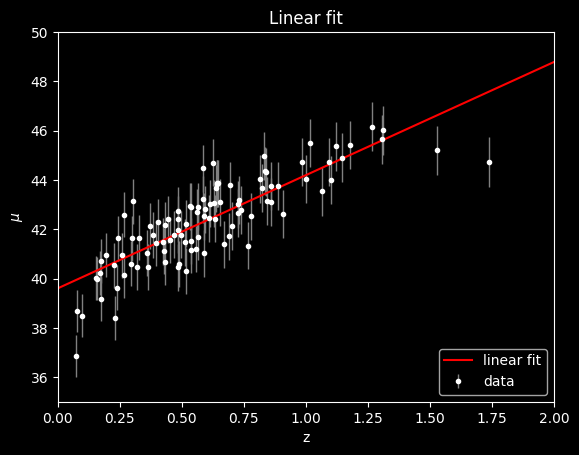

In [4]:
#first we try a linear regression
z_sample=z_sample.reshape(-1,1)

lin_reg = LinearRegression()
lin_reg.fit(z_sample, mu_sample, sample_weight = dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

test_z = np.linspace(0,2,100)
test_mu = theta0 + theta1*test_z

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data', color='white')
plt.plot(test_z, test_mu, 'r', label='linear fit')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Linear fit")
plt.xlim(0,2)
plt.ylim(35,50);

polynomial coefficients for 3 degrees: [38.36452837  8.87820312 -3.06677777  0.17557977]
polynomial coefficients for 4 degrees: [ 36.95622821  21.50098389 -34.55444621  28.77101798  -8.39275909]
polynomial coefficients for 5 degrees: [ 36.09081526  32.02899002 -73.25156852  87.69138092 -47.26697125
   9.15349892]
polynomial coefficients for 6 degrees: [  35.38164335   43.1313125  -128.73943257  210.2480827  -179.32235517
   76.99221964  -13.2572731 ]
polynomial coefficients for 7 degrees: [   33.07559304    87.7120308   -415.17424944  1058.97570095
 -1489.07605606  1161.10280616  -468.28719026    75.87210529]
polynomial coefficients for 8 degrees: [  33.56005026   76.71142746 -328.6942935   732.80233282 -817.31111329
  366.63790671   68.65384194 -116.42734486   28.24788153]
polynomial coefficients for 9 degrees: [   35.1828307     34.56226168    66.26161979 -1105.24083702
  4019.93828695 -7274.00893435  7437.12480885 -4355.02416849
  1361.51277085  -176.16638799]


/tmp/ipykernel_3488/3626044641.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='original data', color='white')


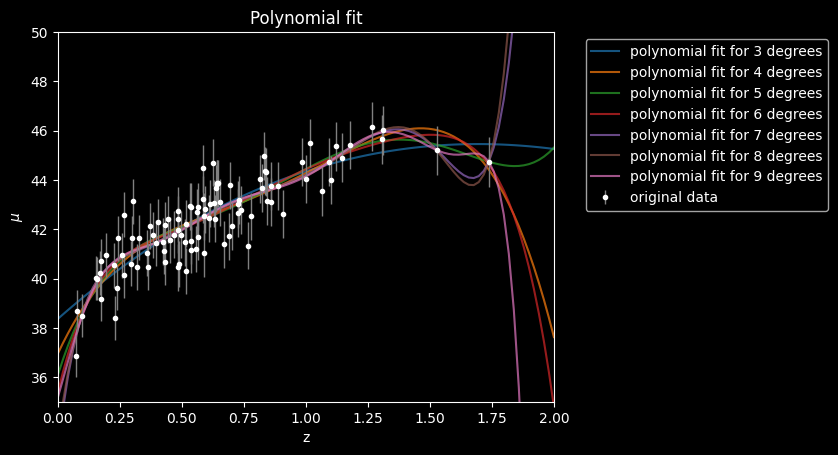

I bet on the 3rd degree or maybe a 4th degree


In [6]:
#polynomial fit 
z_sample=z_sample.reshape(-1,1)
for deg in range(3,10):

    pol_reg = PolynomialRegression(degree=deg)
    pol_reg.fit(z_sample, mu_sample, dmu)
    
    print(f'polynomial coefficients for {deg} degrees: {pol_reg.coef_}')
    
    test_z = np.linspace(0,2,100)
    test_mu = pol_reg.predict(test_z.reshape(-1,1))
    
    
    plt.plot(test_z, test_mu, label=f'polynomial fit for {deg} degrees', alpha=0.7)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='original data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()
print('I bet on the 3rd degree or maybe a 4th degree')

3 degrees: polynomial coefficients [38.57960038  7.27476626 -0.51798032 -0.86859669]
CV error = 1.6055042885081563

4 degrees: polynomial coefficients [ 37.3640657   17.51360893 -24.88099115  20.45090221  -6.07968673]
CV error = 1.0180949595702757

5 degrees: polynomial coefficients [ 36.5741088   26.5045994  -56.24825077  66.1775798  -35.18801018
   6.65996566]
CV error = 4.818090938688502

6 degrees: polynomial coefficients [  36.07771957   33.81800612  -91.27221713  141.02833261 -113.73354421
   46.13897887   -7.57641713]
CV error = 58.720803679707295

7 degrees: polynomial coefficients [   33.34046654    84.76878897  -410.02844573  1064.01218053
 -1508.70624299  1179.38813371  -475.41585267    76.88426962]
CV error = 8.258965337093104

8 degrees: polynomial coefficients [   33.23523246    87.0946033   -427.88912993  1129.88361938
 -1641.56263891  1333.55084466  -577.84759864   113.01918585
    -5.23788742]
CV error = 848.1701641695975

9 degrees: polynomial coefficients [    31.033

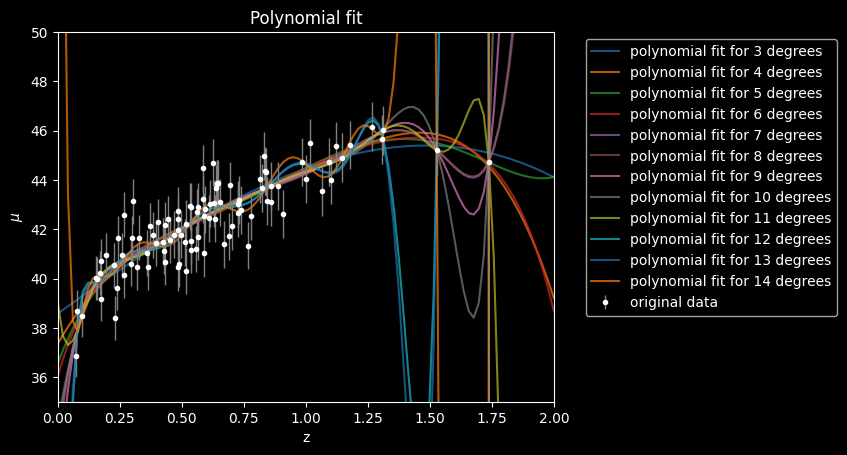

Best degree from CV: 4


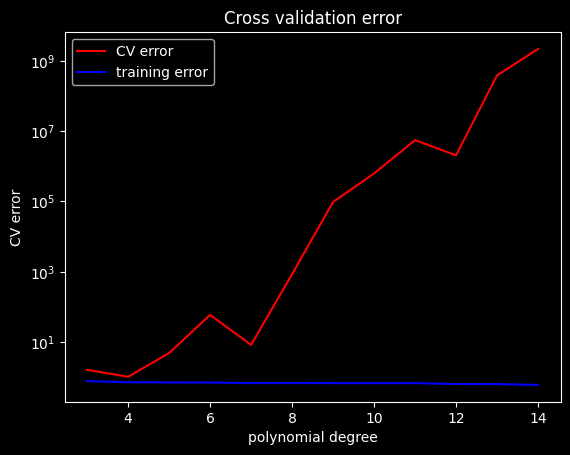

In [40]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

#now we can make a cross validation of the polynomial fit with a k fold cross validation
z_sample=z_sample.reshape(-1,1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores=[]
t_scores=[]
degrees = np.arange(3,15)

for deg in degrees:
    fold_errors=[]
    t_err=[]

    for train_idx, val_idx in kf.split(z_sample):
        X_train, X_val = z_sample[train_idx], z_sample[val_idx]
        y_train, y_val = mu_sample[train_idx], mu_sample[val_idx]
        w_train = 1 / dmu[train_idx]**2

        pol_reg = PolynomialRegression(degree=deg)
        pol_reg.fit(X_train, y_train, w_train)
        y_pred = pol_reg.predict(X_val)
        error = mean_squared_error(y_val, y_pred)
        fold_errors.append(error)
        train_error = mean_squared_error(y_train, pol_reg.predict(X_train))
        t_err.append(train_error)

    print(f'{deg} degrees: polynomial coefficients {pol_reg.coef_}')
    
    test_z = np.linspace(0,2,100)
    test_mu = pol_reg.predict(test_z.reshape(-1,1))
    scores.append(np.mean(fold_errors))
    t_scores.append(np.mean(train_error))
    print(f"CV error = {scores[-1]}\n")

    
    plt.plot(test_z, test_mu, label=f'polynomial fit for {deg} degrees', alpha=0.7)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='original data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

best_deg = degrees[np.argmin(scores)]
print("Best degree from CV:", best_deg)

#plot the traininig and validation errors

plt.plot(degrees, scores, color='red', label='CV error')
plt.plot(degrees, t_scores, color='blue', label='training error')
plt.xlabel("polynomial degree")
plt.ylabel("CV error")
plt.title("Cross validation error")
plt.legend()
plt.yscale('log')
plt.show()

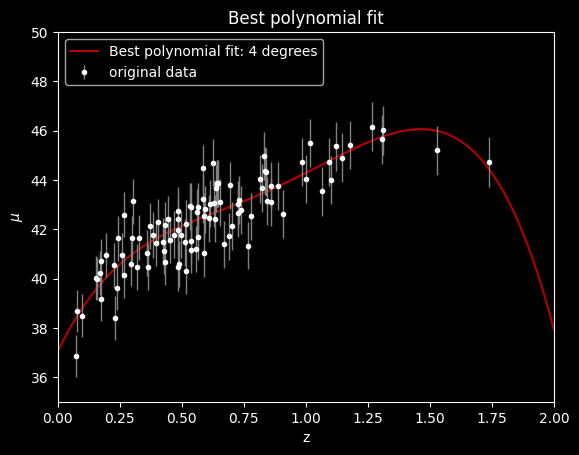

In [41]:
pol_reg = PolynomialRegression(degree=best_deg)
pol_reg.fit(z_sample, mu_sample)

test_z = np.linspace(0,2,100)
test_mu = pol_reg.predict(test_z.reshape(-1,1))

plt.plot(test_z, test_mu, label=f'Best polynomial fit: {best_deg} degrees', alpha=0.7, color='red')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='original data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='upper left')
plt.title("Best polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()